Barplot pour visualier les configurations

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker
import os

In [19]:

print(os.getcwd())

/autofs/unityaccount/cremi/leanguye/projet-deep-learning-m1/resnet50/src/resnet50_RGB/results


le chemin est relatif à la position DU NOTEBOOK dans le dossier de travail. Pas à pwd dans le terminal.

In [5]:
#import des résultats

grid_par_classe_aug = pd.read_csv("grid_search_results_par_classe.csv") 

In [6]:
config_par_classe_aug = grid_par_classe_aug['config'].str.extract(r'(config\d+)') [0]
#autre manière de faire : labels = [f"c{i}" for i in range(len(df_random))] mais ne permet pas de s'assurer que c'est la bonne config



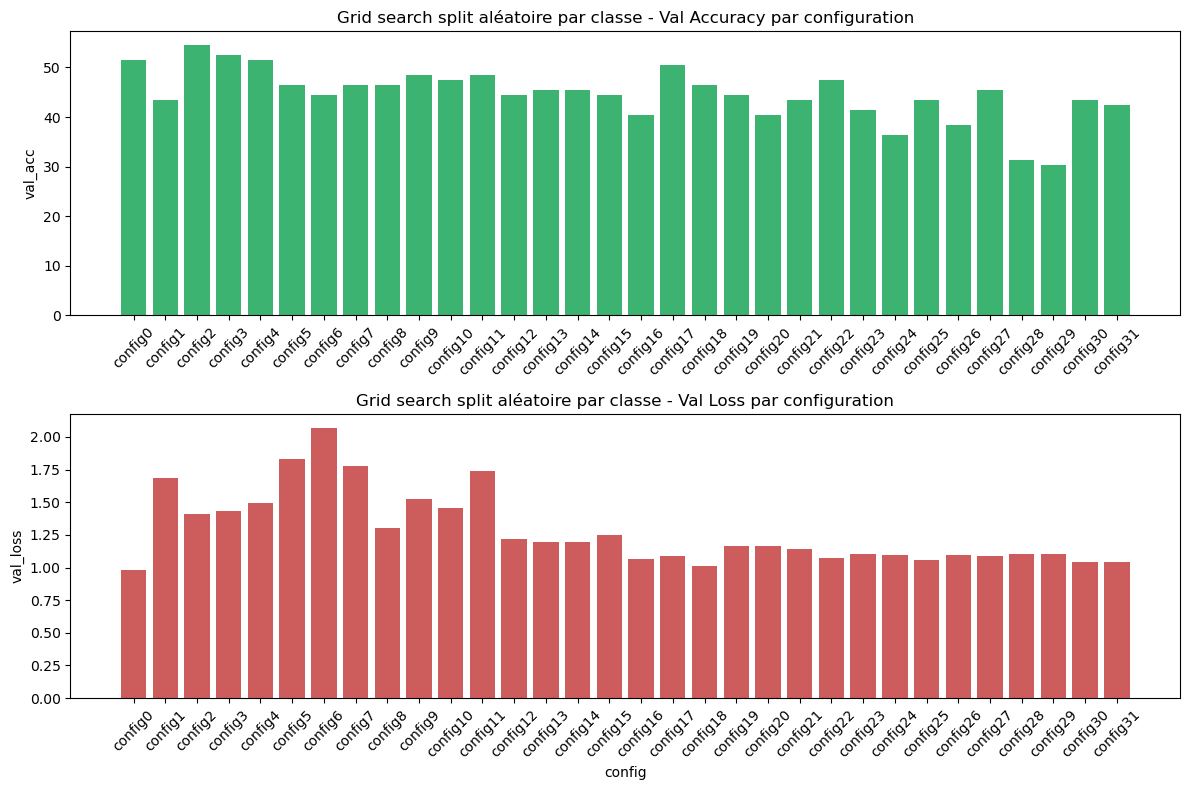

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

#Accuracy

axes[0].bar(config_par_classe_aug, grid_par_classe_aug['val_acc'], color="mediumseagreen")
axes[0].set_title("Grid search split aléatoire par classe - Val Accuracy par configuration")
axes[0].set_ylabel("val_acc")
axes[0].tick_params(axis='x', rotation=45)


axes[1].bar(config_par_classe_aug, grid_par_classe_aug['val_loss'], color='indianred')
axes[1].set_title("Grid search split aléatoire par classe - Val Loss par configuration")
axes[1].set_xlabel("config")
axes[1].set_ylabel("val_loss")
axes[1].tick_params(axis='x', rotation=45)

#plt.title("Grid search split aléatoire par classe - Val Accuracy/Loss par configuration")

plt.tight_layout() #pour que les labels ne se chevauchent pas
plt.show()

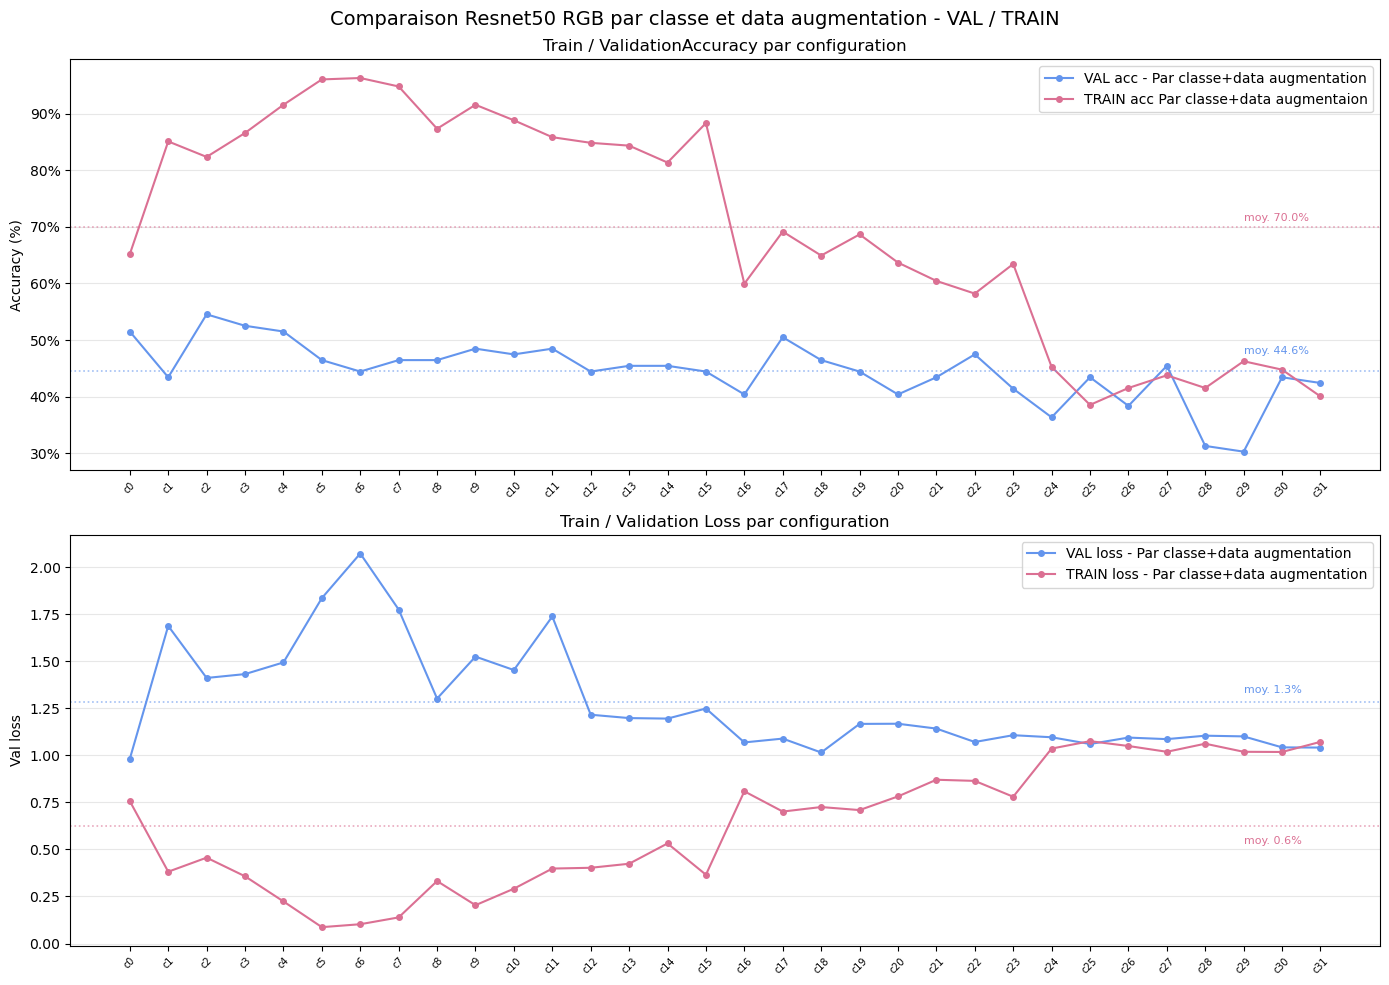

In [14]:
#CLAUDE

labels = [f"c{i}" for i in range(len(grid_par_classe_aug))]

# --- Figure 1 : val_acc comparaison ---

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Comparaison Resnet50 RGB par classe et data augmentation - VAL / TRAIN", fontsize=14)

ax1 = axes[0]
ax1.plot(labels, grid_par_classe_aug["val_acc"],  color="cornflowerblue", linestyle="-",  marker="o", markersize=4, label="VAL acc - Par classe+data augmentation")
ax1.plot(labels, grid_par_classe_aug["train_acc"],  color="palevioletred", linestyle="-",  marker="o", markersize=4, label="TRAIN acc Par classe+data augmentaion")
ax1.axhline(grid_par_classe_aug["val_acc"].mean(),  color="cornflowerblue", linestyle=":", alpha=0.6, linewidth=1.2)
ax1.axhline(grid_par_classe_aug["train_acc"].mean(),  color="palevioletred", linestyle=":", alpha=0.6, linewidth=1.2)
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Train / ValidationAccuracy par configuration")
ax1.legend()
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45, fontsize=7)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax1.grid(axis="y", alpha=0.3)

# Annotations moyennes
ax1.annotate(f"moy. {grid_par_classe_aug['train_acc'].mean():.1f}%", xy=(31, grid_par_classe_aug["train_acc"].mean()),
             xytext=(29, grid_par_classe_aug["train_acc"].mean() + 1), color="palevioletred", fontsize=8)
ax1.annotate(f"moy. {grid_par_classe_aug['val_acc'].mean():.1f}%", xy=(31, grid_par_classe_aug["val_acc"].mean()), #défini les coordonnées du graphique
             xytext=(29, grid_par_classe_aug["val_acc"].mean() + 3), color="cornflowerblue", fontsize=8) #défini les coordonnées précises du graphique ou doit s'afficher le texte

# --- Figure 2 : val_loss comparaison ---
ax2 = axes[1]
ax2.plot(labels, grid_par_classe_aug["val_loss"],  color="cornflowerblue", linestyle="-",  marker="o", markersize=4, label="VAL loss - Par classe+data augmentation")
ax2.plot(labels, grid_par_classe_aug["train_loss"],  color="palevioletred", linestyle="-",  marker="o", markersize=4, label="TRAIN loss - Par classe+data augmentation")
ax2.axhline(grid_par_classe_aug["val_loss"].mean(),  color="cornflowerblue", linestyle=":", alpha=0.6, linewidth=1.2)
ax2.axhline(grid_par_classe_aug["train_loss"].mean(),  color="palevioletred", linestyle=":", alpha=0.6, linewidth=1.2)
ax2.set_ylabel("Val loss")
ax2.set_title("Train / Validation Loss par configuration")
ax2.legend()
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, fontsize=7)
ax2.grid(axis="y", alpha=0.3)

# Annotations moyennes
ax2.annotate(f"moy. {grid_par_classe_aug['train_loss'].mean():.1f}%", xy=(31, grid_par_classe_aug["train_loss"].mean()),
             xytext=(29, grid_par_classe_aug["train_loss"].mean() - 0.1 ), color="palevioletred", fontsize=8)
ax2.annotate(f"moy. {grid_par_classe_aug['val_loss'].mean():.1f}%", xy=(31, grid_par_classe_aug["val_loss"].mean()), #défini les coordonnées du graphique
             xytext=(29, grid_par_classe_aug["val_loss"].mean() + 0.05), color="cornflowerblue", fontsize=8) #défini les coordonnées précises du graphique ou doit s'afficher le texte


plt.tight_layout()
plt.savefig("comparison_val_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
summary = pd.DataFrame({
    "Méthode":         ["Par classe+data augmentation"],
    "Val acc max":     grid_par_classe_aug["val_acc"].max(),
    "Val acc moy":     grid_par_classe_aug["val_acc"].mean(),
    "Val loss min":    grid_par_classe_aug["val_loss"].min(),
    "Val loss moy":    grid_par_classe_aug["val_loss"].mean(),

})
print(summary.to_string(index=False))



                     Méthode  Val acc max  Val acc moy  Val loss min  Val loss moy
Par classe+data augmentation    54.545455    44.602273      0.981008      1.281551
